In [5]:
import pandas as pd

train = pd.read_csv("Skill Gap Analysis/train.csv")
test = pd.read_csv("Skill Gap Analysis/test.csv")

In [7]:
train.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  object 
dtypes: float64(1), int6

In [11]:
test.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,15202,23,Male,B.Tech,Civil,7.32,2,4,5,6,56,6,1,0,Placed
1,4573,24,Female,MCA,ME,4.76,0,1,1,4,37,4,0,3,Not Placed
2,34424,20,Male,BCA,ME,6.16,0,3,3,8,68,6,1,3,Not Placed
3,38881,19,Male,B.Sc,IT,8.77,2,5,8,5,83,6,3,0,Placed
4,30191,23,Male,B.Tech,ME,7.63,0,3,4,6,66,7,1,0,Not Placed


In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            5000 non-null   int64  
 1   Age                   5000 non-null   int64  
 2   Gender                5000 non-null   object 
 3   Degree                5000 non-null   object 
 4   Branch                5000 non-null   object 
 5   CGPA                  5000 non-null   float64
 6   Internships           5000 non-null   int64  
 7   Projects              5000 non-null   int64  
 8   Coding_Skills         5000 non-null   int64  
 9   Communication_Skills  5000 non-null   int64  
 10  Aptitude_Test_Score   5000 non-null   int64  
 11  Soft_Skills_Rating    5000 non-null   int64  
 12  Certifications        5000 non-null   int64  
 13  Backlogs              5000 non-null   int64  
 14  Placement_Status      5000 non-null   object 
dtypes: float64(1), int64(

In [15]:
train.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [17]:
train.drop("Student_ID", axis=1, inplace=True)

In [19]:
train.rename(columns={"Placement_Status_Placed": "Placement_Status"}, inplace=True)

In [21]:
train["Placement_Status"] = train["Placement_Status"].map({
    "Placed": 1,
    "Not Placed": 0
})

In [23]:
train = pd.get_dummies(train, drop_first=True)

In [25]:
train["Placement_Status"].value_counts()

Placement_Status
0    28688
1    16312
Name: count, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split

X = train.drop("Placement_Status", axis=1)
y = train["Placement_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

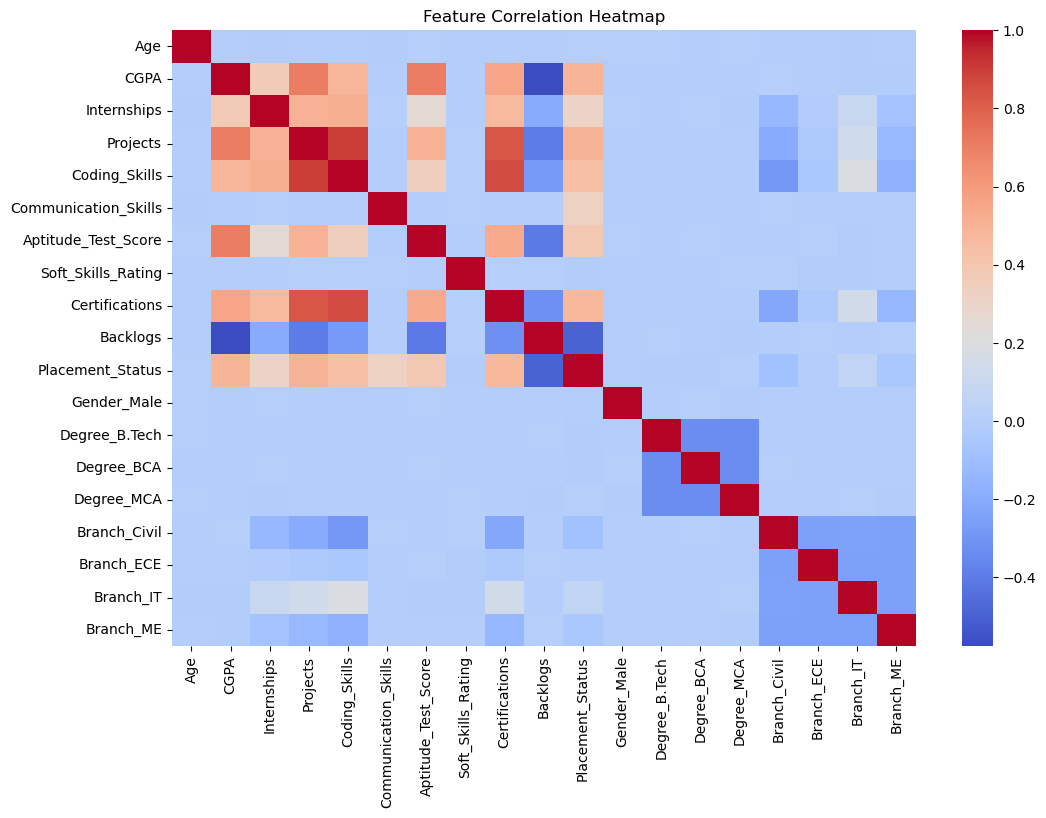

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

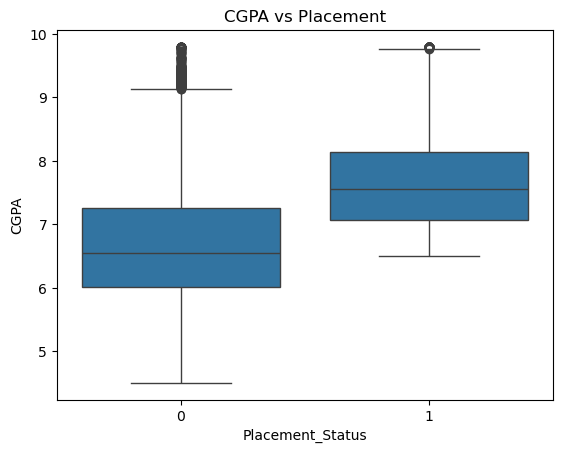

In [35]:
sns.boxplot(x="Placement_Status", y="CGPA", data=train)
plt.title("CGPA vs Placement")
plt.show()

Students with CGPA above 7.5–8 have significantly higher placement probability, indicating academic performance is a key factor in recruitment.

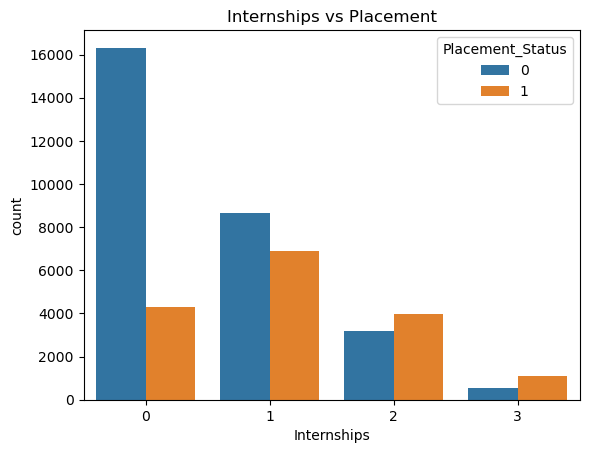

In [38]:
sns.countplot(x="Internships", hue="Placement_Status", data=train)
plt.title("Internships vs Placement")
plt.show()

Students with 1 or more internships show a higher placement rate, highlighting the importance of practical experience.

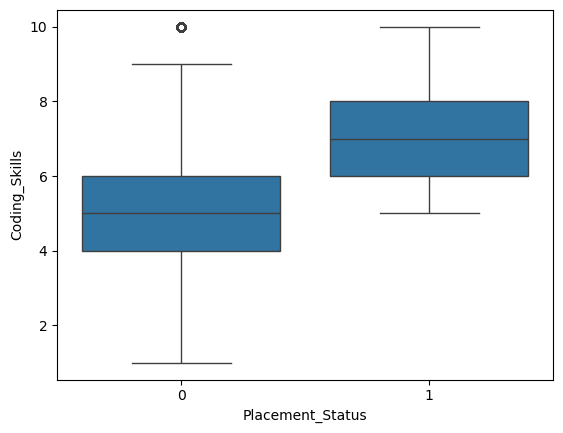

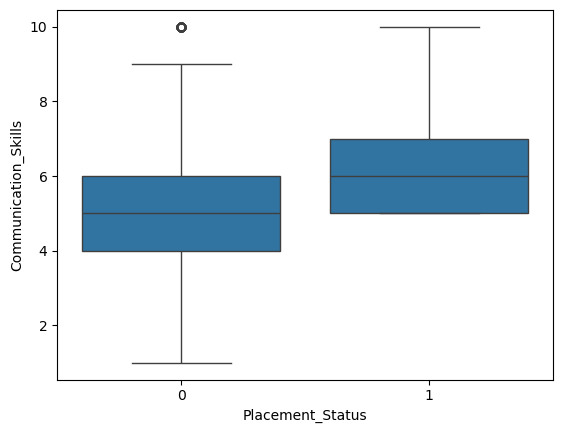

In [41]:
sns.boxplot(x="Placement_Status", y="Coding_Skills", data=train)
plt.show()

sns.boxplot(x="Placement_Status", y="Communication_Skills", data=train)
plt.show()

Higher coding and communication skill scores strongly correlate with successful placements, showing both technical and soft skills are crucial.

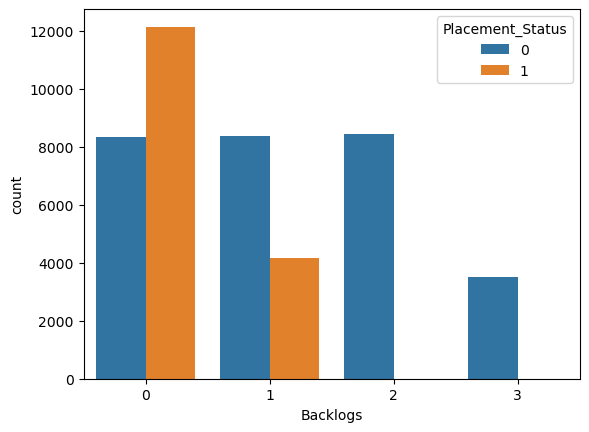

In [44]:
sns.countplot(x="Backlogs", hue="Placement_Status", data=train)
plt.show()

Students with backlogs have noticeably lower placement chances, indicating academic consistency plays a major role.

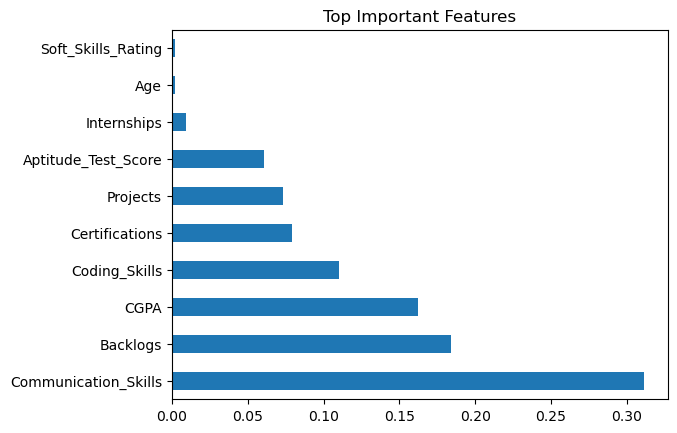

In [51]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

importances = model.feature_importances_

feat_importances = pd.Series(importances, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

Feature importance analysis revealed that communication skills are the most critical factor influencing placement outcomes, followed by academic performance (CGPA), backlogs, and technical skills such as coding. This highlights the importance of both soft skills and academic consistency in employability.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8645555555555555


In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [58]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [60]:
print("LR:", accuracy_score(y_test, y_pred_lr))
print("RF:", accuracy_score(y_test, y_pred_rf))
print("DT:", accuracy_score(y_test, y_pred_dt))

LR: 0.8645555555555555
RF: 1.0
DT: 1.0


In [64]:
print(X.columns)

Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs', 'Gender_Male', 'Degree_B.Tech',
       'Degree_BCA', 'Degree_MCA', 'Branch_Civil', 'Branch_ECE', 'Branch_IT',
       'Branch_ME'],
      dtype='object')


In [66]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

DT Accuracy: 0.9907777777777778


In [68]:
rf = RandomForestClassifier(max_depth=5, n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.9978888888888889


In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9955333333333334


Initial models achieved near-perfect accuracy due to strong correlations among features such as CGPA, communication skills, and backlogs. To prevent overfitting, model complexity was reduced using hyperparameter tuning (max_depth). Cross-validation was applied to ensure robustness, resulting in consistent performance (~99%), indicating the dataset is highly structured and predictable.

In [78]:
feature_names = X.columns.tolist()

pickle.dump(feature_names, open("features.pkl", "wb"))

In [82]:
rf

RandomForestClassifier(max_depth=5)

In [84]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [86]:
import os
print(os.path.getsize("model.pkl"))

227325
